In [1]:
import os
from pathlib import Path
import sys

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import matplotlib.pyplot as plt
import numpy as np
from rich.console import Console
from rich.table import Table

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd if (cwd / "tdmd").exists() else cwd.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from examples.cylinder_flow import (
    CYLINDER_GRID_SHAPE,
    load_cylinder_flow,
    relative_error,
    reconstruct_dmd,
    reconstruct_tdmdii_experiment,
    reshape_snapshot,
)

plt.style.use("ggplot")


In [2]:
data_path = PROJECT_ROOT / "examples" / "data" / "VORTALL.mat"
states, tensor = load_cylinder_flow(data_path)
snapshot_idx = 50


In [3]:
rank = 4
result = reconstruct_dmd(states, rank=rank)
snapshot_true = reshape_snapshot(states[:, snapshot_idx], CYLINDER_GRID_SHAPE)
snapshot_pred = reshape_snapshot(result.reconstructed_states[:, snapshot_idx], CYLINDER_GRID_SHAPE)
snapshot_re = relative_error(states[:, snapshot_idx], result.reconstructed_states[:, snapshot_idx])

table = Table(title="Cylinder Flow DMD")
table.add_column("Name", no_wrap=True)
table.add_column("Value")
table.add_row("state matrix shape", f"{tuple(states.shape)}")
table.add_row("tensor shape", f"{tuple(tensor.shape)}")
table.add_row("rank", f"{rank}")
table.add_row("storage cost", f"{result.storage_cost}")
table.add_row("mean state-wise RE", f"{result.state_errors.mean():.4e}")
table.add_row("snapshot index", f"{snapshot_idx}")
table.add_row("snapshot RE", f"{snapshot_re:.4e}")
Console().print(table)


           Cylinder Flow DMD            
┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Name               ┃ Value           ┃
┡━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ state matrix shape │ (89351, 150)    │
│ tensor shape       │ (199, 150, 449) │
│ rank               │ 4               │
│ storage cost       │ 357414          │
│ mean state-wise RE │ 2.1096e-01      │
│ snapshot index     │ 50              │
│ snapshot RE        │ 2.1209e-01      │
└────────────────────┴─────────────────┘

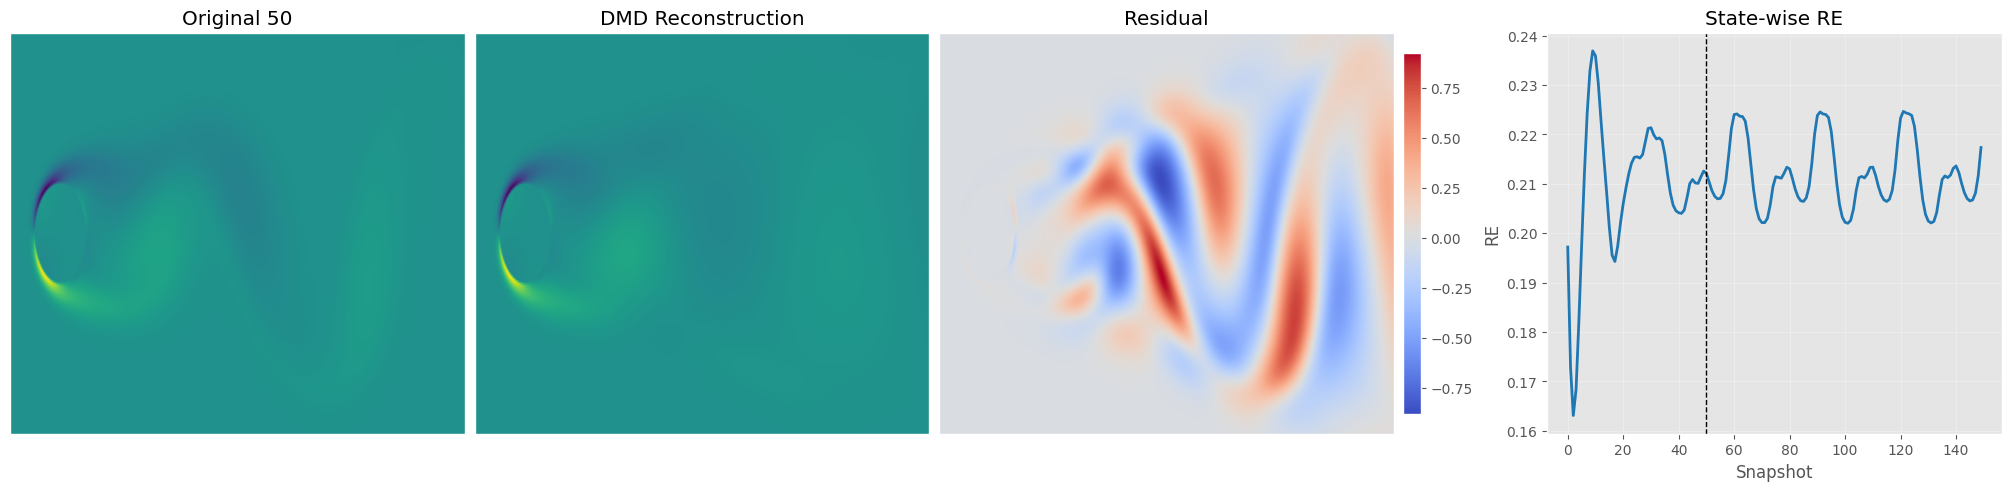

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.8), constrained_layout=True)
axes[0].imshow(np.asarray(snapshot_true), origin="lower", cmap="viridis", aspect="auto")
axes[0].set_title(f"Original {snapshot_idx}")
axes[0].set_xticks([])
axes[0].set_yticks([])

axes[1].imshow(np.asarray(snapshot_pred), origin="lower", cmap="viridis", aspect="auto")
axes[1].set_title("DMD Reconstruction")
axes[1].set_xticks([])
axes[1].set_yticks([])

residual_img = axes[2].imshow(
    np.asarray(snapshot_true - snapshot_pred),
    origin="lower",
    cmap="coolwarm",
    aspect="auto",
)
axes[2].set_title("Residual")
axes[2].set_xticks([])
axes[2].set_yticks([])
fig.colorbar(residual_img, ax=axes[2], shrink=0.9, pad=0.02)

axes[3].plot(result.state_errors, linewidth=2, color="tab:blue")
axes[3].axvline(snapshot_idx, color="black", linestyle="--", linewidth=1)
axes[3].set_title("State-wise RE")
axes[3].set_xlabel("Snapshot")
axes[3].set_ylabel("RE")
axes[3].grid(True, alpha=0.3)

plt.show()
